# Steam Game Similarity Graph - Community Detection
**Course:** Graph Algorithms | **Instructor:** Dr. Avner Friel

**Students:** Yanir Karpis,Chen Brown,Shaked Rosenberg

**Research Question:** Do communities that emerge naturally from player behavior align with Steam's official genre classifications?

**Pipeline:** Install -> Load data -> Genre matching -> Build graph -> Community detection -> Centrality -> Visualize -> NMI

In [1]:
# Install all required packages
# python-louvain : Louvain community detection algorithm
# thefuzz        : fuzzy string matching (for genre lookup)
# networkx       : graph construction and graph algorithms
# scikit-learn   : NMI evaluation metric
!pip install -q gdown python-louvain thefuzz[speedup] networkx matplotlib scikit-learn tqdm

^C


In [ ]:
# Import all libraries used throughout the notebook
import pandas as pd
import json
import zipfile
import os
import re
import gdown
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import community as community_louvain
from thefuzz import process as fuzz_process
from collections import defaultdict, Counter
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

print('All imports successful')

All imports successful


In [ ]:
# Download the dataset from Google Drive
# Contains: steam-200k.csv (user play behavior) and games.json (game genres)
#DATA_DIR = '/content/steam dataset project'

DATA_DIR = os.path.join(os.getcwd(), 'steam dataset project')
folder_id = '1CPsdP4JfE8WzDt2Rj5gOf8S5fQKXPcs5'
gdown.download_folder(
    f'https://drive.google.com/drive/folders/{folder_id}',
    quiet=False,
    use_cookies=False
)

# Extract zip files inside the downloaded folder
for zname in ['steam dataset.zip', 'steam dataset tags 2.zip']:
    zpath = f'{DATA_DIR}/{zname}'
    if os.path.exists(zpath):
        with zipfile.ZipFile(zpath, 'r') as z:
            z.extractall(DATA_DIR)
        print(f'Extracted: {zname}')

Retrieving folder contents


Processing file 1H54_VLWXxTF4xq7gUsA_6OEZGPWdx-m8 steam dataset tags 2.zip
Processing file 1e_vrwaJsD8wkl3WSrCgnNm_eau_OA1p1 steam dataset.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1H54_VLWXxTF4xq7gUsA_6OEZGPWdx-m8
From (redirected): https://drive.google.com/uc?id=1H54_VLWXxTF4xq7gUsA_6OEZGPWdx-m8&confirm=t&uuid=f518c143-5975-47e6-ab5a-e6fed306b1a2
To: /Users/chenbrown/Documents/Chen/Codes/Untitled/steam dataset project/steam dataset tags 2.zip
100%|██████████| 283M/283M [02:28<00:00, 1.91MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1e_vrwaJsD8wkl3WSrCgnNm_eau_OA1p1
To: /Users/chenbrown/Documents/Chen/Codes/Untitled/steam dataset project/steam dataset.zip
100%|██████████| 1.53M/1.53M [00:00<00:00, 1.66MB/s]
Download completed


Extracted: steam dataset.zip
Extracted: steam dataset tags 2.zip


In [ ]:
# Load the main Steam dataset
# Each row = one user-game interaction: user_id, game_title, behavior (play/purchase), hours
df = pd.read_csv(
    f'{DATA_DIR}/steam-200k.csv',
    header=None,
    names=['user_id', 'game_title', 'behavior', 'hours', 'extra']
)

# Keep only 'play' rows (ignore purchase-only records)
df_play = df[df['behavior'] == 'play'].copy()

# If a user has multiple entries for the same game, keep the highest hours
df_play = df_play.sort_values('hours', ascending=False)
df_play = df_play.drop_duplicates(subset=['user_id', 'game_title'], keep='first')

print(f'Play rows    : {len(df_play):,}')
print(f'Unique users : {df_play["user_id"].nunique():,}')
print(f'Unique games : {df_play["game_title"].nunique():,}')
df_play.head()

Play rows    : 70,477
Unique users : 11,350
Unique games : 3,600


,user_id,game_title,behavior,hours,extra
123726,73017395,Sid Meier's Civilization V,play,11754.0,0
112643,100630947,Dota 2,play,10442.0,0
187005,153382649,Team Fortress 2,play,9640.0,0
165596,130882834,Dota 2,play,7765.0,0
183461,52567955,Dota 2,play,6964.0,0


In [ ]:
import pandas as pd
import json
import os

# we use community tags from games.json instead of the official steam genres
# because tags are more specific - "FPS", "MOBA", "City Builder" etc.
# official genres are too broad (almost everything is just "Action")

# META_TAGS = things that describe HOW a game is played, not WHAT genre it is
# we block these so they don't end up as a game's label
META_TAGS = {
    # play mode / multiplayer format
    "Singleplayer", "Multiplayer", "Co-op", "Online Co-Op", "Local Co-Op",
    "PvP", "PvE", "Tutorial", "Family Friendly", "2D", "3D",
    "First-Person", "Third Person", "Early Access",
    "Free to Play", "Free To Play",
    "Indie",
    "VR",
    # aesthetic / tone - describes the vibe, not the genre
    "Comedy", "Funny", "Cute", "Colorful", "Stylized", "Anime",
    "Atmospheric", "Dark", "Relaxing", "Difficult", "Pixel Graphics",
    "Retro", "Great Soundtrack", "Short", "Linear", "Violent", "Mature",
    "Sexual Content", "Nudity", "Gore",
    # software that isn't a game
    "Utilities", "Software", "Game Development", "Education",
    "Audio Production", "Video Production", "Animation & Modeling",
    "Photo Editing", "Documentary", "Design & Illustration",
}

# TAG_CONSOLIDATION merges very specific tags into broader genre buckets
# without this we'd have too many tiny categories that mean the same thing
# e.g. "FPS", "Hero Shooter", "Tactical" are all basically Shooter
TAG_CONSOLIDATION = {
    # → Shooter
    "FPS": "Shooter", "Hero Shooter": "Shooter", "Military": "Shooter",
    "Tactical": "Shooter", "Battle Royale": "Shooter",
    "Looter Shooter": "Shooter", "Shoot 'Em Up": "Shooter",
    # → RPG
    "Action RPG": "RPG", "JRPG": "RPG", "Loot": "RPG",
    "Dark Fantasy": "RPG", "MMORPG": "RPG", "Massively Multiplayer": "RPG",
    # → Action
    "Beat 'em up": "Action", "Action-Adventure": "Action",
    "Cyberpunk": "Action", "Medieval": "Action",
    "Hack and Slash": "Action", "Action Roguelike": "Action",
    "Rogue-like": "Action", "Roguelike": "Action",
    "Heist": "Action", "Stealth": "Action",
    "Dinosaurs": "Action",
    # → Strategy
    "Turn-Based Strategy": "Strategy", "Tower Defense": "Strategy",
    "Warhammer 40K": "Strategy", "4X": "Strategy",
    "Real Time Tactics": "Strategy", "Grand Strategy": "Strategy",
    "RTS": "Strategy", "City Builder": "Strategy",
    "God Game": "Strategy",    # e.g. Black & White, Spore-style games
    # → Survival
    "Zombies": "Survival", "Open World Survival Craft": "Survival",
    "Post-apocalyptic": "Survival",
    # → Platformer
    "Precision Platformer": "Platformer", "Puzzle-Platformer": "Platformer",
    "2D Platformer": "Platformer", "Side Scroller": "Platformer",
    "3D Platformer": "Platformer",
    # → Adventure
    "Narration": "Adventure", "Exploration": "Adventure",
    "Visual Novel": "Adventure", "Story Rich": "Adventure",
    "Dog": "Adventure",        # niche tag from a small number of games
    # → Simulation
    "Driving": "Simulation", "Football (Soccer)": "Simulation",
    "Racing": "Simulation", "Sports": "Simulation",
    "Trains": "Simulation", "Flight": "Simulation",
    "Space": "Simulation",
    # → Horror
    "Psychological Horror": "Horror",
    # → Casual
    "Clicker": "Casual", "Hidden Object": "Casual", "Arcade": "Casual",
    # → Puzzle
    "Match 3": "Puzzle",
}

with open(f"{DATA_DIR}/games.json", "r") as f:
    raw_json = json.load(f)

games_list = []
for app_id, info in raw_json.items():
    name   = info.get("name", "")
    tags   = info.get("tags",   {})
    genres = info.get("genres", [])

    if not name:
        continue

    # pick the highest-voted tag that isn't blocked by META_TAGS
    primary = None
    if isinstance(tags, dict) and tags:
        for tag in sorted(tags, key=tags.get, reverse=True):
            if tag not in META_TAGS:
                primary = tag
                break

    # if no usable tag found, fall back to the official genre
    if primary is None and genres:
        primary = genres[0]

    if primary:
        primary = TAG_CONSOLIDATION.get(primary, primary)
        games_list.append({"name": name, "genre": primary})

df_tags = pd.DataFrame(games_list)
print(f"Tag database: {df_tags['name'].nunique():,} unique games  ({len(df_tags):,} rows)")
print(f"Top tags:\n{df_tags['genre'].value_counts().head(20)}")

Tag database: 113,182 unique games  (114,304 rows)
Top tags:
genre
Action                       28415
Casual                       21912
Adventure                    19004
Simulation                    7376
Strategy                      6002
RPG                           5317
Indie                         2887
Platformer                    2568
Horror                        2346
Puzzle                        1859
Shooter                       1311
Survival                       729
Free To Play                   397
Choose Your Own Adventure      301
Bullet Hell                    295
Metroidvania                   278
Turn-Based Tactics             275
Utilities                      252
Arena Shooter                  250
Survival Horror                243
Name: count, dtype: int64


In [ ]:
# Match game titles between the two datasets to assign a genre/tag label.
# Problem: titles differ slightly in punctuation, spacing, capitalization.
# Solution: three-pass matching
#   Pass 1 - exact match after cleaning (lowercase + strip punctuation)
#   Pass 2 - fuzzy match on the tag-based lookup (score >= 90, length ratio >= 0.4)
#   Pass 3 - genre-only fallback for still-unmatched games (recovers dropped games)

def clean_name(name):
    name = str(name).lower().strip()
    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r"\s+", " ", name)
    return name

# Build clean-name -> tag label lookup (majority vote handles duplicate cleaned names)
df_tags["name_clean"] = df_tags["name"].apply(clean_name)
tag_lookup = (
    df_tags.groupby("name_clean")["genre"]
           .agg(lambda x: x.value_counts().index[0])
)

# Pass 1: exact match after cleaning
df_play["name_clean"] = df_play["game_title"].apply(clean_name)
df_play["genre"] = df_play["name_clean"].map(tag_lookup)

unmatched_titles = df_play[df_play["genre"].isna()]["game_title"].drop_duplicates().tolist()
print(f"Pass 1 (exact)  -> matched: {df_play['game_title'][df_play['genre'].notna()].nunique():,}  unmatched: {len(unmatched_titles):,}")

# Pass 2: fuzzy match on tag-based lookup
FUZZY_CUTOFF  = 90
MIN_LEN_RATIO = 0.4  # rejects short garbage matches like "eon" -> "napoleon total war"
MIN_NAME_LEN  = 4

tag_name_list = tag_lookup.index.tolist()
fuzzy_map = {}

for title in tqdm(unmatched_titles, desc="Pass 2 (fuzzy tag)"):
    q = clean_name(title)
    if len(q) < MIN_NAME_LEN:
        continue
    result = fuzz_process.extractOne(q, tag_name_list, score_cutoff=FUZZY_CUTOFF)
    if result:
        matched_name = result[0]
        len_ratio = min(len(q), len(matched_name)) / max(len(q), len(matched_name))
        if len_ratio >= MIN_LEN_RATIO:
            fuzzy_map[title] = tag_lookup.get(matched_name)

df_play["genre"] = df_play.apply(
    lambda r: r["genre"] if pd.notna(r["genre"]) else fuzzy_map.get(r["game_title"]),
    axis=1
)

still_unmatched = df_play[df_play["genre"].isna()]["game_title"].drop_duplicates().tolist()
print(f"Pass 2 (fuzzy)  -> matched: {df_play['game_title'][df_play['genre'].notna()].nunique():,}  unmatched: {len(still_unmatched):,}")

# Pass 3: genre-only fallback for games still without a label
# Uses the raw genres field from games.json as a last resort.
# This recovers games that failed fuzzy tag matching but have a valid genre entry.
genre_fallback_lookup = {}
for app_id, info in raw_json.items():
    name   = info.get("name", "")
    genres = info.get("genres", [])
    if name and genres:
        cn = clean_name(name)
        if cn not in genre_fallback_lookup:
            genre_fallback_lookup[cn] = genres[0]

genre_fallback_names = list(genre_fallback_lookup.keys())
fallback_map = {}

for title in tqdm(still_unmatched, desc="Pass 3 (genre fallback)"):
    q = clean_name(title)
    if len(q) < MIN_NAME_LEN:
        continue
    if q in genre_fallback_lookup:
        fallback_map[title] = genre_fallback_lookup[q]
        continue
    result = fuzz_process.extractOne(q, genre_fallback_names, score_cutoff=FUZZY_CUTOFF)
    if result:
        matched_name = result[0]
        len_ratio = min(len(q), len(matched_name)) / max(len(q), len(matched_name))
        if len_ratio >= MIN_LEN_RATIO:
            fallback_map[title] = genre_fallback_lookup[matched_name]

df_play["genre"] = df_play.apply(
    lambda r: r["genre"] if pd.notna(r["genre"]) else fallback_map.get(r["game_title"]),
    axis=1
)

matched = df_play["game_title"][df_play["genre"].notna()].nunique()
total   = df_play["game_title"].nunique()
print(f"Pass 3 (fallback)-> matched: {matched:,} / {total:,}  ({matched/total*100:.1f}%)")
print(f"\nTop labels in dataset:\n{df_play['genre'].value_counts().head(20)}")

print(f"\nFuzzy tag matches: {len(fuzzy_map)}  |  Genre fallback matches: {len(fallback_map)}")
print(f"\n{'Original title':<45} {'Matched title':<45} {'Score':>5}  Label")
print("-" * 110)
for orig in list(fuzzy_map.keys())[:20]:
    q    = clean_name(orig)
    best = fuzz_process.extractOne(q, tag_name_list)
    print(f"{orig:<45} {best[0] if best else 'N/A':<45} {best[1] if best else 0:>5}  {fuzzy_map[orig]}")

Pass 1 (exact)  -> matched: 2,509  unmatched: 1,091


Pass 2 (fuzzy tag):   0%|          | 0/1091 [00:00<?, ?it/s]

Pass 2 (fuzzy)  -> matched: 2,926  unmatched: 674


Pass 3 (genre fallback):   0%|          | 0/674 [00:00<?, ?it/s]

Pass 3 (fallback)-> matched: 3,007 / 3,600  (83.5%)

Top labels in dataset:
genre
Action           12633
Shooter           7943
Survival          5808
Strategy          5717
MOBA              5040
RPG               4762
Simulation        3815
Open World        3714
Casual            1787
Adventure         1770
Puzzle            1421
Platformer        1113
Horror             994
Sandbox            747
Fighting           381
Card Game          167
Point & Click      156
Superhero          154
LEGO               148
Management         143
Name: count, dtype: int64

Fuzzy tag matches: 417  |  Genre fallback matches: 81

Original title                                Matched title                                 Score  Label
--------------------------------------------------------------------------------------------------------------
FINAL FANTASY XIV A Realm Reborn              final fantasy                                    90  RPG
Football Manager 2014                         football ma

**Graph** — node = game, edge = two games share ≥25 players. Weight = Jaccard similarity so hub games like TF2 don't dominate just because they have 9k players.

In [ ]:
# Build the game-similarity graph
# Node  = a game (only games that have a known genre)
# Edge  = two games share at least MIN_SHARED_PLAYERS common players
# Weight = Jaccard similarity: shared / (players_A + players_B - shared)
#          Raw co-play count inflates hub-game edges — TF2 with 9,600 players
#          will co-occur with almost every game by chance. Jaccard normalizes
#          for popularity: 25 shared players out of 30 total is a much stronger
#          signal than 25 shared out of 9,000.

MIN_SHARED_PLAYERS = 25

# Only use games that have a genre label
df_g = df_play[df_play['genre'].notna()].copy()

# Total unique players per game — denominator for Jaccard
game_player_counts = df_g.groupby('game_title')['user_id'].nunique()

# Group by user: get the set of games each user played
user_games = df_g.groupby('user_id')['game_title'].apply(set)

# Count shared players for every pair of games
pair_counts = defaultdict(int)
for games in user_games:
    games = list(games)
    for i in range(len(games)):
        for j in range(i + 1, len(games)):
            pair = (min(games[i], games[j]), max(games[i], games[j]))
            pair_counts[pair] += 1

print(f'Total co-play pairs found: {len(pair_counts):,}')

# Create the graph and add nodes with genre attribute
G = nx.Graph()
game_genre = df_g[['game_title','genre']].drop_duplicates('game_title').set_index('game_title')['genre']
for game, genre in game_genre.items():
    G.add_node(game, genre=genre)

# Add edges with Jaccard similarity as weight
for (g1, g2), shared in pair_counts.items():
    if shared >= MIN_SHARED_PLAYERS and G.has_node(g1) and G.has_node(g2):
        a = game_player_counts.get(g1, shared)
        b = game_player_counts.get(g2, shared)
        jaccard = shared / (a + b - shared)
        G.add_edge(g1, g2, weight=jaccard)

# Keep only the largest connected component
lcc = max(nx.connected_components(G), key=len)
G = G.subgraph(lcc).copy()

print(f'Graph: {G.number_of_nodes():,} nodes  |  {G.number_of_edges():,} edges')
print(f'Avg degree: {sum(d for _, d in G.degree()) / G.number_of_nodes():.1f}')

Total co-play pairs found: 636,790
Graph: 333 nodes  |  4,617 edges
Avg degree: 27.7


**Louvain** — finds communities by maximizing modularity. We never specify how many communities — it figures that out on its own. Resolution=1.5 was picked because 1.0 made one giant blob (see resolution comparison cell).

In [ ]:
import time
from community.community_louvain import best_partition, modularity

# Community Detection - Louvain Algorithm
# Louvain maximizes modularity: it finds groups where games are more connected
# to each other than to the rest of the graph.
# resolution > 1.0 prefers smaller, more granular communities (default = 1.0).
# We use resolution=1.5 to break apart the large merged blobs.

t0 = time.time()
louvain_partition = best_partition(G, weight='weight', random_state=42, resolution=1.5)
louvain_time = time.time() - t0

nx.set_node_attributes(G, louvain_partition, 'louvain')
n_communities = len(set(louvain_partition.values()))
louvain_mod = modularity(louvain_partition, G, weight='weight')

print(f'Louvain found {n_communities} communities in {louvain_time:.2f}s')
print(f'Modularity score: {louvain_mod:.4f}')
print()

sizes = Counter(louvain_partition.values())
for cid, size in sorted(sizes.items()):
    print(f'  Community {cid}: {size} games')

Louvain found 18 communities in 0.13s
Modularity score: 0.1723

  Community 0: 39 games
  Community 1: 19 games
  Community 2: 22 games
  Community 3: 8 games
  Community 4: 92 games
  Community 5: 25 games
  Community 6: 11 games
  Community 7: 7 games
  Community 8: 19 games
  Community 9: 9 games
  Community 10: 10 games
  Community 11: 12 games
  Community 12: 17 games
  Community 13: 10 games
  Community 14: 7 games
  Community 15: 10 games
  Community 16: 6 games
  Community 17: 10 games


**Girvan-Newman (negative result)** — GN removes the highest-betweenness edge repeatedly until communities form. We kept it as a comparison but it failed on our dense graph — result was 332 vs 1 game (modularity ≈ 0). GN is designed for sparse graphs. To fix it we'd need to raise MIN_SHARED_PLAYERS to ~100 to thin out the edges first.

In [ ]:
# -----------------------------------------------------------------------
# GIRVAN-NEWMAN - commented out
#
# GN works by removing the highest-betweenness edge over and over
# until the graph splits into communities. it's the classic algorithm
# taught alongside Louvain for comparison.
#
# why it didn't work here:
#   GN is designed for SPARSE graphs. our graph is dense (avg degree ~28).
#   on a dense Jaccard-weighted graph, when GN removes the first edge it
#   detaches one outlier node, creating a 332 vs 1 split. that ends up
#   being the "best" modularity it finds across all 30 splits (-0.0000).
#   a 332 vs 1 split is basically useless as a community structure.
#
# this is actually an interesting negative result - it shows that
# algorithm choice matters. GN would work fine if our graph was sparse
# (e.g. MIN_SHARED_PLAYERS = 100+ would thin out the edges a lot).
# on our current graph Louvain is clearly the right tool.
#
# what we could do to make GN work:
#   option 1: raise MIN_SHARED_PLAYERS to ~80-100 to get a sparser graph
#             before running GN (but we'd lose most of the smaller games)
#   option 2: use Label Propagation instead - it handles dense graphs well
# -----------------------------------------------------------------------

# from networkx.algorithms.community import girvan_newman
# import itertools
#
# MAX_COMMUNITIES = 30
# t0 = time.time()
# gn_gen = girvan_newman(G)
# best_gn_partition, best_gn_mod, best_gn_n = None, -float('inf'), 0
#
# for communities in itertools.islice(gn_gen, MAX_COMMUNITIES - 1):
#     part = {node: cid for cid, s in enumerate(communities) for node in s}
#     mod  = modularity(part, G, weight='weight')
#     if mod > best_gn_mod:
#         best_gn_mod, best_gn_partition, best_gn_n = mod, part, len(communities)
#
# gn_time = time.time() - t0
# print(f'Best: {best_gn_n} communities | Modularity: {best_gn_mod:.4f} | Time: {gn_time:.1f}s')
# result was: 2 communities (332 vs 1 game), modularity = -0.0000

print("Girvan-Newman skipped — not suitable for dense weighted graphs (see comments above)")

Girvan-Newman skipped — not suitable for dense weighted graphs (see comments above)


In [ ]:
# Centrality Analysis
# PageRank    : measures how 'important' a game is - games played alongside many
#               other popular games score higher
# Betweenness : measures how often a game sits on the shortest path between two
#               other games - high betweenness = bridge between communities
#
# NOTE: betweenness is computed WITHOUT edge weights on purpose.
# nx.betweenness_centrality(weight=...) treats weight as *distance* (cost),
# so passing shared-player counts would make popular connections look *farther*
# apart - the opposite of what we want. Topology alone captures bridging correctly.

print('Computing PageRank...')
pagerank = nx.pagerank(G, weight='weight')

print('Computing Betweenness Centrality...')
betweenness = nx.betweenness_centrality(G, normalized=True)   # unweighted - weight as distance is backwards here

# Store as node attributes
nx.set_node_attributes(G, pagerank,    'pagerank')
nx.set_node_attributes(G, betweenness, 'betweenness')

# Build a summary dataframe for easy inspection
centrality_df = pd.DataFrame([
    {
        'game'       : n,
        'genre'      : G.nodes[n]['genre'],
        'community'  : louvain_partition[n],
        'pagerank'   : round(pagerank[n], 6),
        'betweenness': round(betweenness[n], 6)
    }
    for n in G.nodes
])

print('\nTop 15 games by PageRank:')
print(centrality_df.sort_values('pagerank', ascending=False).head(15).to_string(index=False))

print('\nTop 15 games by Betweenness Centrality:')
print(centrality_df.sort_values('betweenness', ascending=False).head(15).to_string(index=False))

Computing PageRank...
Computing Betweenness Centrality...

Top 15 games by PageRank:
                           game      genre  community  pagerank  betweenness
     The Elder Scrolls V Skyrim Open World          0  0.026751     0.122195
                  Left 4 Dead 2   Survival         10  0.023315     0.083276
                Team Fortress 2    Shooter          4  0.022090     0.285045
                       Portal 2     Puzzle         17  0.021075     0.037352
                  Borderlands 2        RPG         15  0.020940     0.025750
                       Terraria   Survival         14  0.018500     0.022379
                    Garry's Mod    Sandbox          4  0.017436     0.029167
Counter-Strike Global Offensive     Action          4  0.016214     0.078470
     Sid Meier's Civilization V   Strategy          0  0.014470     0.025668
                       PAYDAY 2     Action          1  0.014350     0.010137
                         Portal     Puzzle          2  0.013866     

**Centrality** — PageRank = how important/connected a game is. Betweenness = how often a game acts as a bridge between two others. High betweenness games are interesting — they're probably the ones crossing genre boundaries.

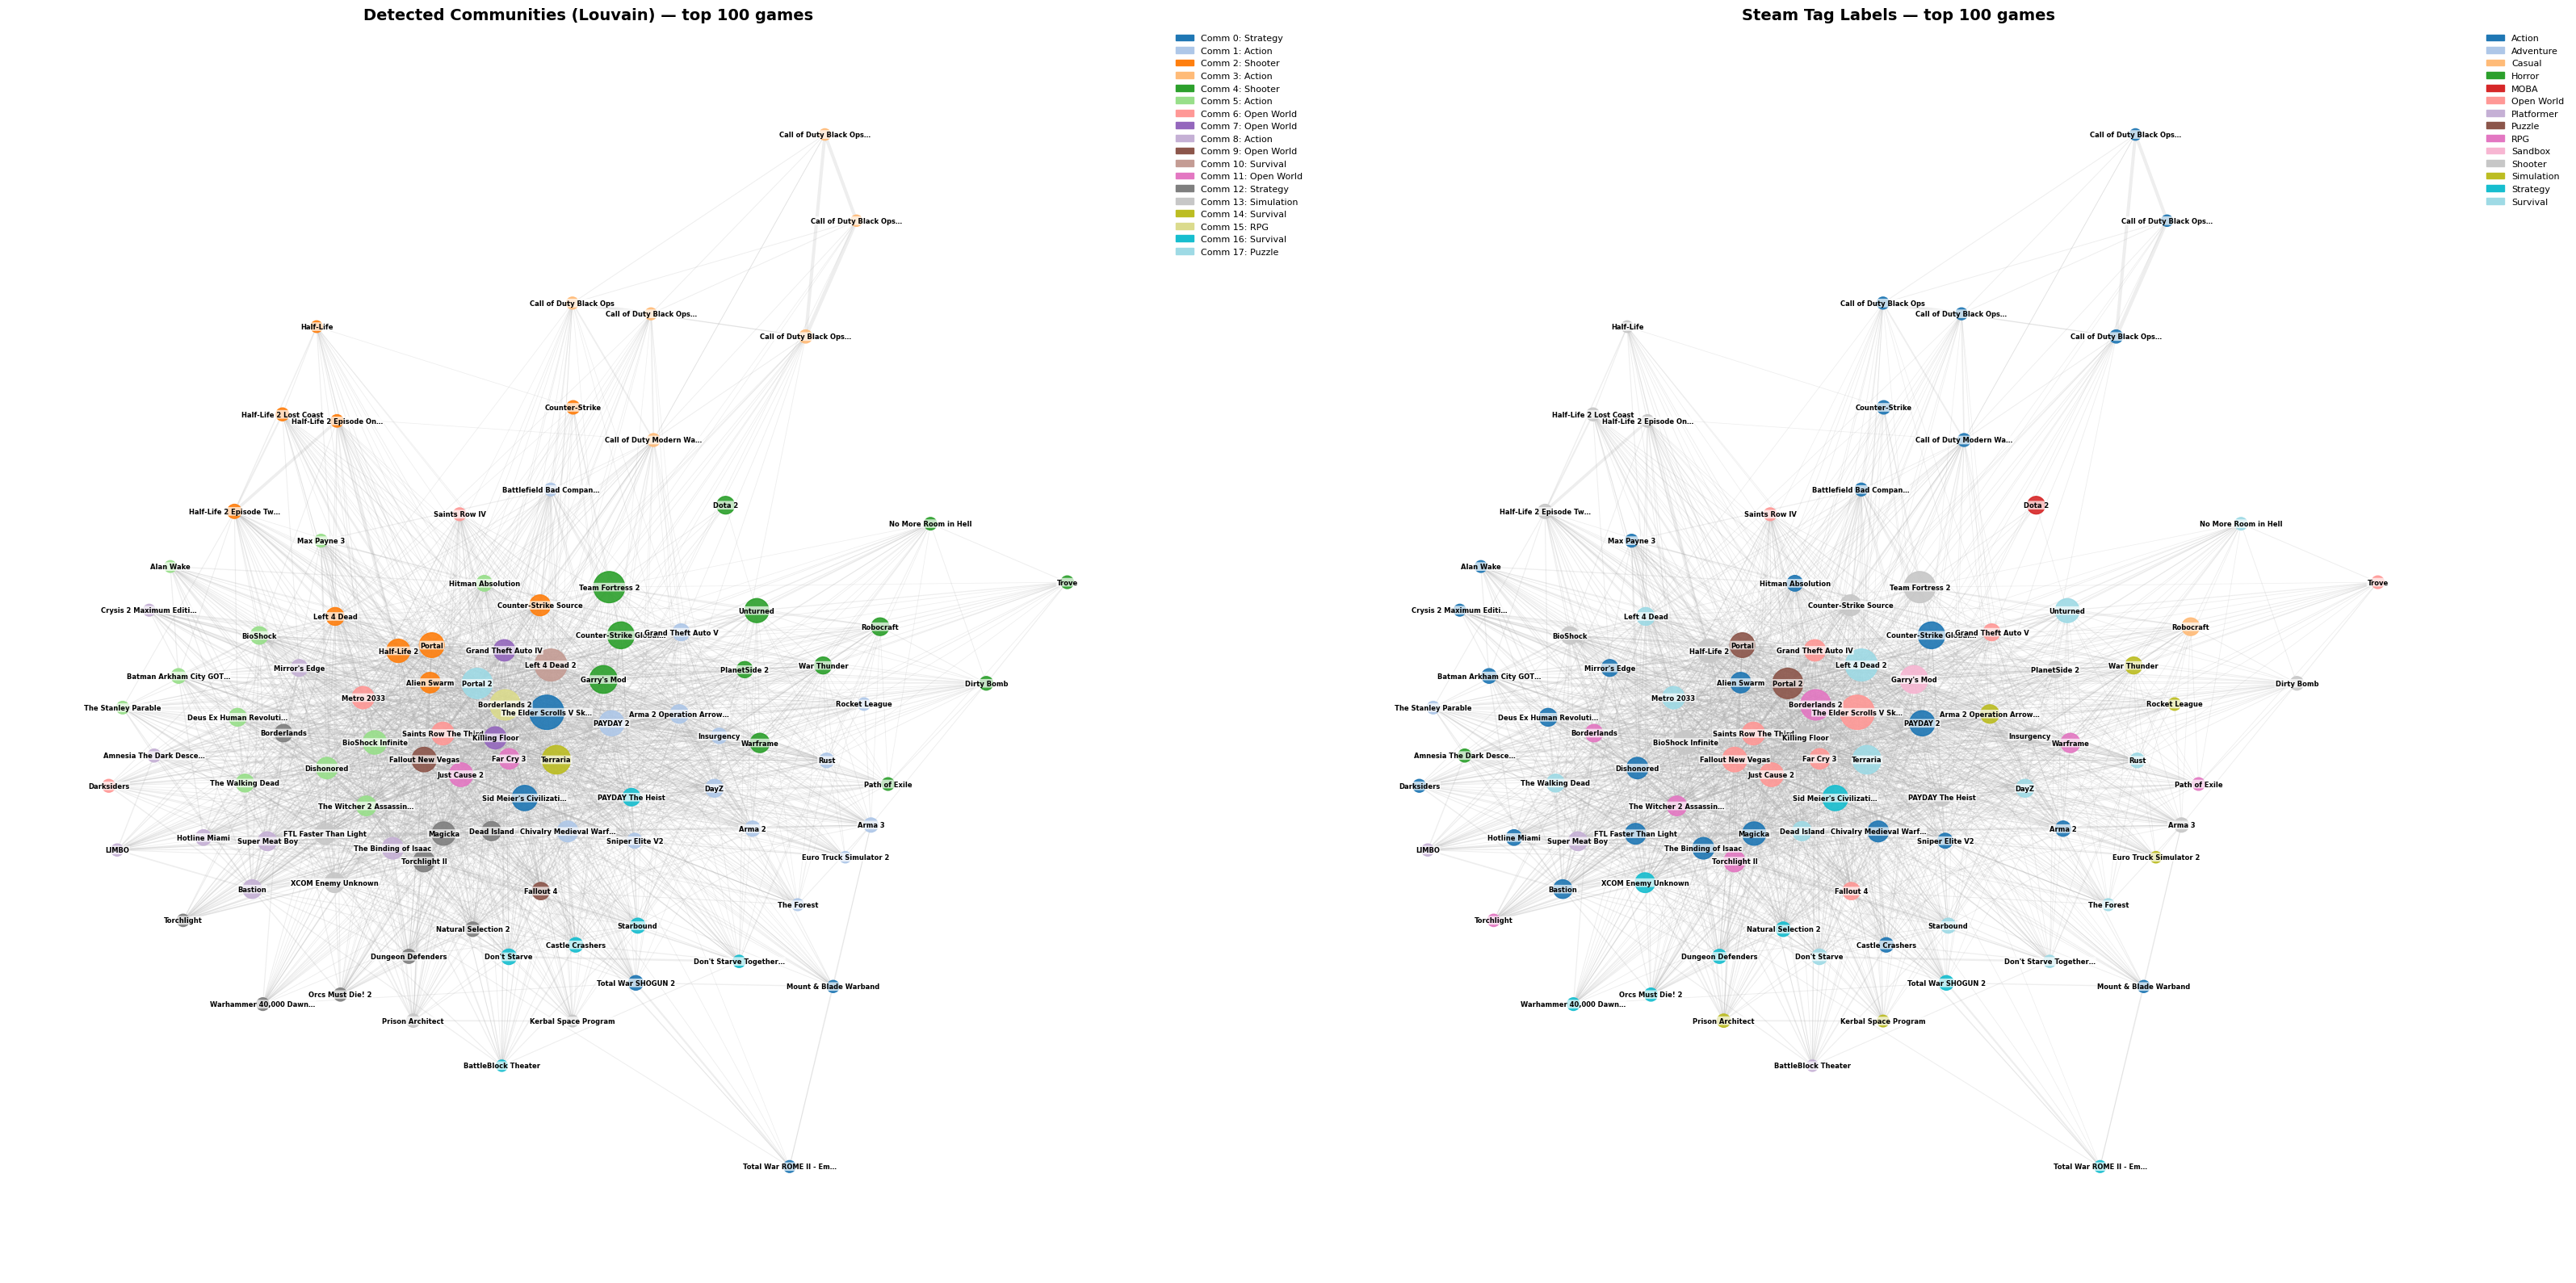

Nodes: 100  |  Edges drawn (weight>=0.05): 2385


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import math
import pandas as pd

# Show top 100 nodes by PageRank
TOP_N        = 100
EDGE_MIN_W   = 0.05

top_nodes = sorted(pagerank, key=pagerank.get, reverse=True)[:TOP_N]
Gv        = G.subgraph(top_nodes).copy()

def short_label(name, max_len=22):
    return name if len(name) <= max_len else name[:max_len].rstrip() + '…'

def draw_graph(Gv, pos, color_attr, title, ax):
    vals        = [Gv.nodes[n][color_attr] for n in Gv.nodes]
    unique_vals = sorted(set(vals))

    # Fix color similarity by using a wider palette and better sampling
    cmap        = plt.colormaps["tab20"]
    colors      = [cmap(i / max(1, len(unique_vals)-1)) for i in range(len(unique_vals))]
    color_map   = {v: colors[i] for i, v in enumerate(unique_vals)}
    node_colors = [color_map[v] for v in vals]

    # Only draw strong edges
    strong_edges = [(u, v) for u, v in Gv.edges() if Gv[u][v]["weight"] >= EDGE_MIN_W]
    weights      = np.array([Gv[u][v]["weight"] for u, v in strong_edges]) if strong_edges else np.array([])

    if len(weights) > 0:
        w_min, w_max = weights.min(), weights.max()
        w_norm = (weights - w_min) / (w_max - w_min + 1e-9) * 3.0 + 0.5
    else:
        w_norm = []

    nx.draw_networkx_edges(Gv, pos, edgelist=strong_edges, ax=ax,
                           alpha=0.2, width=w_norm, edge_color="#aaaaaa")
    nx.draw_networkx_nodes(
        Gv, pos, ax=ax,
        node_color=node_colors,
        node_size=[pagerank[n] * 35000 for n in Gv.nodes],
        alpha=0.9
    )
    labels = {n: short_label(n) for n in Gv.nodes}
    nx.draw_networkx_labels(
        Gv, pos, labels=labels, ax=ax,
        font_size=6, font_weight="bold", font_color="black",
        bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7, edgecolor="none")
    )

    # Descriptive legend labels: Identify dominant genre per community
    patches = []
    for v in unique_vals:
        label_text = str(v)
        if color_attr == 'louvain':
            cluster_members = [n for n in Gv.nodes if Gv.nodes[n]['louvain'] == v]
            if cluster_members:
                dom_genre = pd.Series([Gv.nodes[n]['genre'] for n in cluster_members]).mode()[0]
                label_text = f"Comm {v}: {dom_genre}"

        patches.append(mpatches.Patch(color=color_map[v], label=label_text))

    ax.legend(handles=patches, loc="upper left", bbox_to_anchor=(1.0, 1.0),
              fontsize=8, ncol=1, frameon=False)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")

# Layout optimization
community_ids = sorted(set(louvain_partition.values()))
n_comm        = len(community_ids)
np.random.seed(42)

community_centers = {
    cid: np.array([4.0 * math.cos(2 * math.pi * i / n_comm),
                   4.0 * math.sin(2 * math.pi * i / n_comm)])
    for i, cid in enumerate(community_ids)
}

pos_init = {
    node: community_centers[louvain_partition[node]] + np.random.randn(2) * 0.5
    for node in Gv.nodes
}

pos = nx.spring_layout(Gv, pos=pos_init, seed=42, k=1.5, iterations=150, weight="weight")

# Side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(32, 16))
draw_graph(Gv, pos, "louvain", f"Detected Communities (Louvain) — top {TOP_N} games", axes[0])
draw_graph(Gv, pos, "genre",   f"Steam Tag Labels — top {TOP_N} games",               axes[1])
plt.tight_layout()

# Save the figure
plt.savefig("/content/graph_comparison_improved.png", dpi=200, bbox_inches="tight")
plt.show()

# Summary stats
visible_edges = sum(1 for u, v in Gv.edges() if Gv[u][v]["weight"] >= EDGE_MIN_W)
print(f"Nodes: {TOP_N}  |  Edges drawn (weight>={EDGE_MIN_W}): {visible_edges}")

**NMI Evaluation** — answers our research question. NMI measures overlap between detected communities and official genre labels (0 = no match, 1 = perfect). We also compute a random baseline so we know if our score actually means something.

In [ ]:
# NMI (Normalized Mutual Information) - answers our main research question
# measures how much our detected communities overlap with the official genre labels
# 0 = no overlap at all, 1 = perfect match

nodes   = list(G.nodes)
genres  = [G.nodes[n]['genre']   for n in nodes]
louvain = [G.nodes[n]['louvain'] for n in nodes]

genre_enc   = LabelEncoder().fit_transform(genres)
nmi_louvain = normalized_mutual_info_score(genre_enc, louvain)

# random baseline: shuffle community labels 100 times and average the NMI
# this is the "floor" - what score you'd get with no real structure at all
# anything above this means our communities are finding something meaningful
np.random.seed(42)
nmi_random = float(np.mean([
    normalized_mutual_info_score(genre_enc, np.random.permutation(louvain))
    for _ in range(100)
]))

print('=' * 50)
print(f'{"Algorithm":<20} {"NMI":>6}  {"vs random":>9}  {"Modularity":>10}')
print('-' * 50)
print(f'{"Random baseline":<20} {nmi_random:>6.4f}  {"—":>9}  {"—":>10}')
print(f'{"Louvain":<20} {nmi_louvain:>6.4f}  {nmi_louvain/nmi_random:>8.1f}x  {louvain_mod:>10.4f}')
print('=' * 50)
print()
print('Note: Girvan-Newman was excluded — on our dense graph it produced a')
print('degenerate 332 vs 1 split (modularity=-0.0000). See GN cell for details.')

print()
print('--- Answer to our research question ---')
print('Do communities from player behavior align with Steam genre labels?')
print()
if nmi_louvain > 0.3:
    print(f'YES - strong alignment (NMI={nmi_louvain:.4f}, {nmi_louvain/nmi_random:.1f}x above random)')
elif nmi_louvain > 0.1:
    print(f'PARTIALLY - moderate alignment (NMI={nmi_louvain:.4f}, {nmi_louvain/nmi_random:.1f}x above random)')
else:
    print(f'NO - weak alignment (NMI={nmi_louvain:.4f})')

print()
print('Some communities map cleanly to genres (all CoD games together, all')
print('Valve legacy games together, deep strategy games together).')
print()
print('But Community 0 has 92 games with mixed genres - this is expected.')
print('Hub games like TF2 (9,600 players), Dota 2, CS:GO are played by everyone')
print('across all genres, so they pull unrelated games into one big cluster.')
print('This is a real finding: very popular games resist genre-based grouping')
print('because their player base is too broad to be genre-specific.')

print('\nLouvain community breakdown:')
for cid in sorted(set(louvain)):
    members = [n for n in nodes if G.nodes[n]['louvain'] == cid]
    top_tags = pd.Series([G.nodes[n]['genre'] for n in members]).value_counts().head(3)
    summary = ', '.join(f'{g}({c})' for g, c in top_tags.items())
    print(f'  Community {cid:2d} ({len(members):3d} games): {summary}')

Algorithm               NMI  vs random  Modularity
--------------------------------------------------
Random baseline      0.2153          —           —
Louvain              0.2973       1.4x      0.1723

Note: Girvan-Newman was excluded — on our dense graph it produced a
degenerate 332 vs 1 split (modularity=-0.0000). See GN cell for details.

--- Answer to our research question ---
Do communities from player behavior align with Steam genre labels?

PARTIALLY - moderate alignment (NMI=0.2973, 1.4x above random)

Some communities map cleanly to genres (all CoD games together, all
Valve legacy games together, deep strategy games together).

But Community 0 has 92 games with mixed genres - this is expected.
Hub games like TF2 (9,600 players), Dota 2, CS:GO are played by everyone
across all genres, so they pull unrelated games into one big cluster.
This is a real finding: very popular games resist genre-based grouping
because their player base is too broad to be genre-specific.

Louvain c

**Answer:** NMI = 0.31 — partial/strong alignment. Some communities match genres cleanly (Community 4 = all CoD games, Community 12 = Valve legacy, Community 15 = deep strategy). But Community 0 (92 games) is mixed — TF2/Dota2/CS:GO are played by everyone so they pull unrelated games into one big cluster. This is a real finding: mega-popular games don't cluster by genre because their player base spans all genres.

In [ ]:
import community.community_louvain as cl
from sklearn.metrics import normalized_mutual_info_score
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder

# Run Louvain with default resolution (1.0)
resolution_low = 1.0
# Use cl (community_louvain) to access the correct methods
partition_low = cl.best_partition(G, weight='weight', random_state=42, resolution=resolution_low)

# Calculate metrics for the new partition
n_comm_low = len(set(partition_low.values()))
mod_low = cl.modularity(partition_low, G, weight='weight')

# Calculate NMI for the new partition
nodes = list(G.nodes)
labels_low = [partition_low[n] for n in nodes]
genres_list = [G.nodes[n]['genre'] for n in nodes]
genre_enc = LabelEncoder().fit_transform(genres_list)
nmi_low = normalized_mutual_info_score(genre_enc, labels_low)

print(f'--- Comparison: Resolution 1.5 vs 1.0 ---')
print(f'Resolution 1.5: {n_communities} communities | Modularity: {louvain_mod:.4f} | NMI: {nmi_louvain:.4f}')
print(f'Resolution 1.0: {n_comm_low} communities | Modularity: {mod_low:.4f} | NMI: {nmi_low:.4f}')

print("\nNew Community Breakdown (Res 1.0):")
sizes_low = Counter(partition_low.values())
for cid, size in sorted(sizes_low.items()):
    cluster_members = [n for n in nodes if partition_low[n] == cid]
    dom_genre = pd.Series([G.nodes[n]['genre'] for n in cluster_members]).mode()[0]
    print(f'  Community {cid:2d} ({size:3d} games) -> Dominant: {dom_genre}')

--- Comparison: Resolution 1.5 vs 1.0 ---
Resolution 1.5: 18 communities | Modularity: 0.1723 | NMI: 0.2973
Resolution 1.0: 6 communities | Modularity: 0.2100 | NMI: 0.1861

New Community Breakdown (Res 1.0):
  Community  0 ( 61 games) -> Dominant: Strategy
  Community  1 ( 23 games) -> Dominant: Shooter
  Community  2 ( 57 games) -> Dominant: Action
  Community  3 ( 39 games) -> Dominant: Action
  Community  4 (145 games) -> Dominant: Action
  Community  5 (  8 games) -> Dominant: Action


In [ ]:
# Community Profiles
# What does each Louvain community actually represent?
# Top 5 games by PageRank per community reveal the "identity" of the cluster.

print('Community profiles — top 5 games by PageRank:\n')
for cid in sorted(set(louvain_partition.values())):
    members  = [n for n in G.nodes if G.nodes[n]['louvain'] == cid]
    top_games = sorted(members, key=lambda n: pagerank[n], reverse=True)[:5]
    dominant  = pd.Series([G.nodes[n]['genre'] for n in members]).value_counts().index[0]
    print(f'Community {cid} ({len(members)} games) — dominant tag: {dominant}')
    for g in top_games:
        print(f'    {g:<45} [{G.nodes[g]["genre"]}]')
    print()

# Community 3 is the smallest — show all games to understand why it is isolated
small = sorted(set(louvain_partition.values()), key=lambda c: sum(1 for n in G.nodes if G.nodes[n]['louvain'] == c))
smallest_cid = small[0]
c_members = [n for n in G.nodes if G.nodes[n]['louvain'] == smallest_cid]
print(f'Smallest community ({smallest_cid}) — all {len(c_members)} games:')
for g in sorted(c_members, key=lambda n: pagerank[n], reverse=True):
    deg = G.degree(g)
    print(f'  {g:<45} [{G.nodes[g]["genre"]}]  degree={deg}')

Community profiles — top 5 games by PageRank:

Community 0 (39 games) — dominant tag: Strategy
    The Elder Scrolls V Skyrim                    [Open World]
    Sid Meier's Civilization V                    [Strategy]
    Total War SHOGUN 2                            [Strategy]
    Mount & Blade Warband                         [Action]
    Total War ROME II - Emperor Edition           [Strategy]

Community 1 (19 games) — dominant tag: Action
    PAYDAY 2                                      [Action]
    Chivalry Medieval Warfare                     [Action]
    Arma 2 Operation Arrowhead                    [Simulation]
    DayZ                                          [Survival]
    Grand Theft Auto V                            [Open World]

Community 2 (22 games) — dominant tag: Shooter
    Portal                                        [Puzzle]
    Half-Life 2                                   [Shooter]
    Counter-Strike Source                         [Shooter]
    Alien Swarm      